# UTS Kasus 1 Data Tabular (Deep Learning)

Nama : Rio Ramadhani Harllambang

NIM : 1202220205

Kelas : SI-46-EDM

## API Token Kaggle

In [1]:
mkdir -p ~/.kaggle && echo KGAT_77778d82436b57f31950aa6d250920ae > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

## Load Titanic Data
Muat dataset pelatihan dan pengujian Titanic yang telah diunduh oleh `kagglehub` ke dalam DataFrame pandas untuk diproses lebih lanjut.


In [2]:
import pandas as pd
import kagglehub
import os

# Download the Titanic competition files
competition_path = kagglehub.competition_download('titanic')

# Construct the full paths to the training and testing datasets
train_csv_path = os.path.join(competition_path, 'train.csv')
test_csv_path = os.path.join(competition_path, 'test.csv')

# Load the Titanic training dataset
train_df = pd.read_csv(train_csv_path)

# Load the Titanic testing dataset
test_df = pd.read_csv(test_csv_path)

print("Titanic Training DataFrame (train_df):")
print(train_df.head())
print("\nTitanic Testing DataFrame (test_df):")
print(test_df.head())

100%|██████████| 34.1k/34.1k [00:00<00:00, 5.14MB/s]

Extracting files...
Titanic Training DataFrame (train_df):
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        

### Deskripsi Dataset Tambahan

Dataset Titanic yang dimuat terdiri dari data pelatihan (`train_df`) dengan **891** baris dan data pengujian (`test_df`) dengan **418** baris. Masing-masing baris merepresentasikan seorang penumpang.

Fitur-fitur utama yang tersedia meliputi `PassengerId`, `Survived` (hanya di data pelatihan), `Pclass`, `Name`, `Sex`, `Age`, `SibSp`, `Parch`, `Ticket`, `Fare`, `Cabin`, dan `Embarked`.

Beberapa tantangan utama dalam dataset ini adalah:
*   **Nilai Hilang**: Terutama pada kolom `Age`, `Cabin`, `Fare`, dan `Embarked`.
*   **Variabel Kategorikal**: Beberapa fitur bersifat kategorikal (`Sex`, `Embarked`, `Pclass`, `Title` yang diekstraksi) yang memerlukan encoding.
*   **Fitur Tidak Relevan**: Kolom seperti `Name`, `Ticket` mungkin tidak langsung berguna dan perlu diolah atau dihapus.

Distribusi kelas untuk target `Survived` (1 = selamat, 0 = tidak selamat) adalah sebagai berikut:

*   **Tidak Selamat (0):** 549 penumpang (sekitar 61.6%) dari total 891 penumpang
*   **Selamat (1):** 342 penumpang (sekitar 38.4%) dari total 891 penumpang

Ini menunjukkan adanya ketidakseimbangan kelas ringan, di mana jumlah penumpang yang tidak selamat lebih banyak daripada yang selamat.

## Eksplorasi Data (EDA)

Bagian ini melakukan analisis data eksplorasi untuk memahami distribusi data, hubungan antar variabel, dan mengidentifikasi pola potensial. Di bagian ini akan memvisualisasikan distribusi data dan hubungannya dengan variabel target 'Survived'.

/tmp/ipykernel_23340/3952252226.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=train_df, palette='viridis')


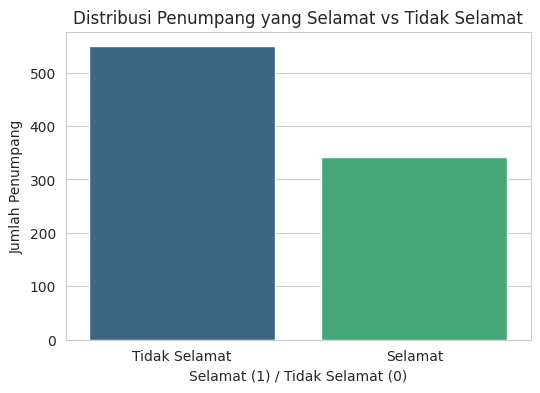

/tmp/ipykernel_23340/3952252226.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=train_df, palette='mako')


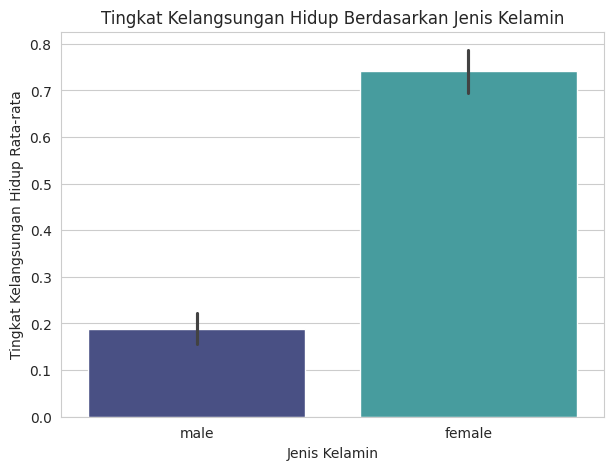

/tmp/ipykernel_23340/3952252226.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=train_df, palette='flare')


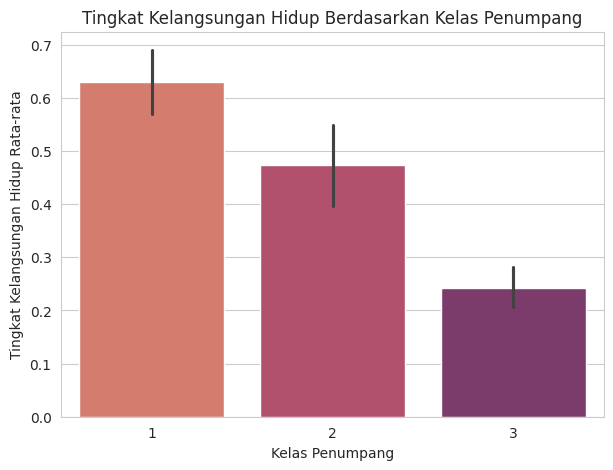

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style('whitegrid')

# 1. Distribusi Kelas Target (Survived)
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=train_df, palette='viridis')
plt.title('Distribusi Penumpang yang Selamat vs Tidak Selamat')
plt.xlabel('Selamat (1) / Tidak Selamat (0)')
plt.ylabel('Jumlah Penumpang')
plt.xticks([0, 1], ['Tidak Selamat', 'Selamat'])
plt.show()

# 2. Tingkat Kelangsungan Hidup Berdasarkan Jenis Kelamin
plt.figure(figsize=(7, 5))
sns.barplot(x='Sex', y='Survived', data=train_df, palette='mako')
plt.title('Tingkat Kelangsungan Hidup Berdasarkan Jenis Kelamin')
plt.xlabel('Jenis Kelamin')
plt.ylabel('Tingkat Kelangsungan Hidup Rata-rata')
plt.show()

# 3. Tingkat Kelangsungan Hidup Berdasarkan Kelas Penumpang (Pclass)
plt.figure(figsize=(7, 5))
sns.barplot(x='Pclass', y='Survived', data=train_df, palette='flare')
plt.title('Tingkat Kelangsungan Hidup Berdasarkan Kelas Penumpang')
plt.xlabel('Kelas Penumpang')
plt.ylabel('Tingkat Kelangsungan Hidup Rata-rata')
plt.show()

Dari visualisasi di atas, dapat diamati beberapa hal:

*   **Distribusi Target (Survived)**: Terlihat adanya ketidakseimbangan kelas, di mana jumlah penumpang yang tidak selamat (0) lebih banyak daripada yang selamat (1). Ini perlu diperhatikan saat melatih model.
*   **Tingkat Kelangsungan Hidup Berdasarkan Jenis Kelamin (Sex)**: Wanita memiliki tingkat kelangsungan hidup yang jauh lebih tinggi dibandingkan pria. Ini adalah salah satu prediktor terkuat dalam dataset Titanic.
*   **Tingkat Kelangsungan Hidup Berdasarkan Kelas Penumpang (Pclass)**: Penumpang di kelas 1 memiliki tingkat kelangsungan hidup tertinggi, diikuti oleh kelas 2, dan terakhir kelas 3. Hal ini menunjukkan adanya korelasi kuat antara status sosial/ekonomi dengan peluang bertahan hidup.

## Pra-pemrosesan Data untuk Deep Learning

Langkah pertama adalah membersihkan dan menyiapkan data untuk pelatihan model deep learning. Ini mencakup penanganan nilai yang hilang, rekayasa fitur, dan pengkodean variabel kategorikal.

In [4]:
# Gabungkan DataFrame pelatihan dan pengujian untuk pra-pemrosesan konsisten
combined_df = pd.concat([train_df.drop('Survived', axis=1), test_df], ignore_index=True)

# Tinjau nilai yang hilang
print("\nJumlah nilai yang hilang di setiap kolom (gabungan DataFrame):")
print(combined_df.isnull().sum()[combined_df.isnull().sum() > 0])



Jumlah nilai yang hilang di setiap kolom (gabungan DataFrame):
Age          263
Fare           1
Cabin       1014
Embarked       2
dtype: int64


### Penanganan Nilai yang Hilang

*   **Usia (Age)**: Akan diisi dengan median dari kolom Usia.
*   **Embarked**: Akan diisi dengan mode (nilai paling sering muncul) dari kolom Embarked.
*   **Fare**: Akan diisi dengan median dari kolom Fare (hanya ada di test_df).
*   **Cabin**: Kolom ini memiliki terlalu banyak nilai yang hilang. Untuk saat ini, kita akan menghapusnya.

In [5]:
# Isi nilai Usia (Age) yang hilang dengan median
combined_df['Age'] = combined_df['Age'].fillna(combined_df['Age'].median())

# Isi nilai Embarked yang hilang dengan mode
combined_df['Embarked'] = combined_df['Embarked'].fillna(combined_df['Embarked'].mode()[0])

# Isi nilai Fare yang hilang dengan median
combined_df['Fare'] = combined_df['Fare'].fillna(combined_df['Fare'].median())

# Hapus kolom Cabin karena terlalu banyak nilai yang hilang, jika kolom tersebut masih ada
if 'Cabin' in combined_df.columns:
    combined_df.drop('Cabin', axis=1, inplace=True)

print("\nJumlah nilai yang hilang setelah penanganan:")
print(combined_df.isnull().sum()[combined_df.isnull().sum() > 0])


Jumlah nilai yang hilang setelah penanganan:
Series([], dtype: int64)


### Rekayasa Fitur (Feature Engineering)

*   **FamilySize**: Kombinasikan `SibSp` (jumlah saudara/pasangan) dan `Parch` (jumlah orang tua/anak) untuk membuat fitur ukuran keluarga.
*   **IsAlone**: Buat fitur biner yang menunjukkan apakah penumpang bepergian sendiri atau tidak.
*   **Title**: Ekstrak gelar dari nama penumpang (misalnya, Mr., Mrs., Miss, Master) yang seringkali mengindikasikan status sosial atau usia.

In [6]:
# Buat fitur FamilySize
combined_df['FamilySize'] = combined_df['SibSp'] + combined_df['Parch'] + 1

# Buat fitur IsAlone
combined_df['IsAlone'] = 0
combined_df.loc[combined_df['FamilySize'] == 1, 'IsAlone'] = 1

# Ekstrak Title dari kolom Nama
combined_df['Title'] = combined_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Kelompokkan beberapa gelar yang jarang menjadi 'Rare'
combined_df['Title'] = combined_df['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
combined_df['Title'] = combined_df['Title'].replace('Mlle', 'Miss')
combined_df['Title'] = combined_df['Title'].replace('Ms', 'Miss')
combined_df['Title'] = combined_df['Title'].replace('Mme', 'Mrs')

print("\nDistribusi Title setelah pengelompokan:")
print(combined_df['Title'].value_counts())


Distribusi Title setelah pengelompokan:
Title
Mr        757
Miss      264
Mrs       198
Master     61
Rare       29
Name: count, dtype: int64


### Pengkodean Fitur Kategorikal dan Penskalaan Fitur Numerik

*   **One-Hot Encoding**: Gunakan One-Hot Encoding untuk fitur kategorikal seperti `Sex`, `Embarked`, `Pclass`, dan `Title`.
*   **Penskalaan (Scaling)**: Gunakan StandardScaler untuk fitur numerik seperti `Age`, `Fare`, dan `FamilySize` agar model deep learning dapat belajar lebih efektif.
*   **Penghapusan Fitur yang Tidak Digunakan**: Hapus kolom asli yang tidak lagi diperlukan (`Name`, `Ticket`, `SibSp`, `Parch`). `PassengerId` akan disimpan secara terpisah untuk membuat file submission.

In [7]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Definisikan fitur numerik dan kategorikal
numeric_features = ['Age', 'Fare', 'FamilySize']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title', 'IsAlone'] # PClass juga bisa dianggap kategorikal

# Buat pipeline pra-pemrosesan
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Pisahkan kembali data pelatihan dan pengujian
train_passenger_ids = train_df['PassengerId']
test_passenger_ids = test_df['PassengerId']

X_combined = combined_df.drop(['PassengerId', 'Name', 'Ticket', 'SibSp', 'Parch'], axis=1)
y_train = train_df['Survived']

# Terapkan pra-pemrosesan
X_processed = preprocessor.fit_transform(X_combined)

# Ubah kembali ke DataFrame untuk kemudahan inspeksi (opsional, bisa langsung ke numpy array untuk DL)
# Dapatkan nama fitur setelah one-hot encoding
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names)

X_train_processed = X_processed_df.iloc[:len(train_df)]
X_test_processed = X_processed_df.iloc[len(train_df):]

print("\nBentuk X_train_processed:", X_train_processed.shape)
print("Bentuk X_test_processed:", X_test_processed.shape)
print("\nBeberapa baris pertama dari data yang diproses (pelatihan):")
print(X_train_processed.head())



Bentuk X_train_processed: (891, 18)
Bentuk X_test_processed: (418, 18)

Beberapa baris pertama dari data yang diproses (pelatihan):
        Age      Fare  FamilySize  Pclass_1  Pclass_2  Pclass_3  Sex_female  \
0 -0.581628 -0.503291    0.073352       0.0       0.0       1.0         0.0   
1  0.658652  0.734744    0.073352       1.0       0.0       0.0         1.0   
2 -0.271558 -0.490240   -0.558346       0.0       0.0       1.0         1.0   
3  0.426099  0.383183    0.073352       1.0       0.0       0.0         1.0   
4  0.426099 -0.487824   -0.558346       0.0       0.0       1.0         0.0   

   Sex_male  Embarked_C  Embarked_Q  Embarked_S  Title_Master  Title_Miss  \
0       1.0         0.0         0.0         1.0           0.0         0.0   
1       0.0         1.0         0.0         0.0           0.0         0.0   
2       0.0         0.0         0.0         1.0           0.0         1.0   
3       0.0         0.0         0.0         1.0           0.0         0.0   
4      

## Membangun Model Deep Learning (MLP)


Ringkasan Model MLP:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,801 (50.00 KB)

 Trainable params: 12,801 (50.00 KB)

 Non-trainable params: 0 (0.00 B)


Melatih Model MLP...
Pelatihan selesai.

Accuracy pada data pelatihan: 0.8552


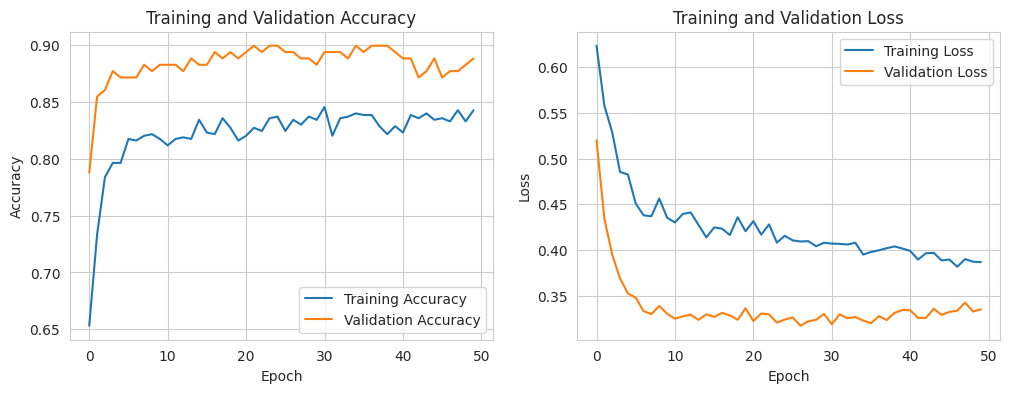

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import time

# Definisikan arsitektur model MLP
model = keras.Sequential([
    keras.Input(shape=(X_train_processed.shape[1],)), # Explicit Input layer
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')  # Output layer untuk klasifikasi biner
])

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Tampilkan ringkasan model
print("\nRingkasan Model MLP:")
model.summary()

# Latih model dan ukur waktu pelatihan
print("\nMelatih Model MLP...")
start_time = time.time()
history = model.fit(X_train_processed, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)
end_time = time.time()
training_time = end_time - start_time

print("Pelatihan selesai.")

# Evaluasi model pada data pelatihan
loss, accuracy = model.evaluate(X_train_processed, y_train, verbose=0)
print(f"\nAccuracy pada data pelatihan: {accuracy:.4f}")

# Plot history untuk visualisasi (opsional)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Membuat Prediksi dan File Submission

In [9]:
# Lakukan prediksi pada data pengujian
predictions = model.predict(X_test_processed)

# Konversi probabilitas ke kelas biner (0 atau 1)
predictions_binary = (predictions > 0.5).astype(int)

# Buat DataFrame submission
submission_df = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Survived': predictions_binary.flatten()
})

# Simpan ke file CSV
submission_path = 'case1_submission_dl.csv'
submission_df.to_csv(submission_path, index=False)

print(f"File submission berhasil dibuat di: {submission_path}")
print("\nHead dari file submission:")
print(submission_df.head())

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
File submission berhasil dibuat di: case1_submission_dl.csv

Head dari file submission:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1


## Analisis Error

Bagian ini bertujuan untuk menganalisis contoh-contoh di mana model membuat prediksi yang salah pada data pelatihan. Memahami jenis kesalahan yang dibuat model dapat memberikan wawasan tentang keterbatasannya dan mengarahkan pada perbaikan lebih lanjut (misalnya, rekayasa fitur tambahan, penyesuaian arsitektur model).

In [10]:
# Lakukan prediksi pada data pelatihan untuk analisis error
y_train_pred_probs = model.predict(X_train_processed)
y_train_pred = (y_train_pred_probs > 0.5).astype(int)

# Bandingkan prediksi dengan label sebenarnya
misclassified_indices = y_train_pred.flatten() != y_train.values

# Ambil data pelatihan asli yang salah diklasifikasikan
misclassified_train_df = train_df[misclassified_indices].copy()

# Tambahkan kolom prediksi dan label sebenarnya
misclassified_train_df['Actual_Survived'] = y_train[misclassified_indices]
misclassified_train_df['Predicted_Survived'] = y_train_pred[misclassified_indices].flatten()

print(f"Jumlah data pelatihan yang salah diklasifikasikan: {len(misclassified_train_df)}")
print("\nBeberapa contoh data yang salah diklasifikasikan:")
display(misclassified_train_df.head())

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Jumlah data pelatihan yang salah diklasifikasikan: 129

Beberapa contoh data yang salah diklasifikasikan:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Actual_Survived,Predicted_Survived
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,0
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,1,0
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S,1,0
21,22,1,2,"Beesley, Mr. Lawrence",male,34.0,0,0,248698,13.0000,D56,S,1,0
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5000,A6,S,1,0


Dari contoh-contoh yang salah diklasifikasikan di atas, kita dapat mulai mencari pola. Beberapa hal yang bisa dipertimbangkan dalam analisis error:

1.  **Lihat Fitur-fitur Utama**: Apakah ada karakteristik tertentu (usia, jenis kelamin, kelas penumpang, ukuran keluarga, dll.) yang menonjol pada penumpang yang salah diklasifikasikan?
2.  **Periksa Konflik Data**: Apakah ada data yang tampaknya "sulit" untuk diklasifikasikan karena nilai fiturnya ambigu atau berada di "garis batas" keputusan model?
3.  **Kasus False Positives vs. False Negatives**: Coba pisahkan antara kasus di mana model memprediksi selamat padahal tidak (False Positive) dan tidak selamat padahal selamat (False Negative). Masing-masing mungkin memiliki pola yang berbeda.

Misalnya, jika model sering salah mengklasifikasikan pria muda di Pclass 3 sebagai 'Selamat', padahal mereka tidak, ini mungkin menunjukkan bahwa model terlalu optimis untuk kelompok demografi tersebut. Sebaliknya, jika wanita tua di Pclass 1 sering diprediksi 'Tidak Selamat' padahal mereka selamat, ini bisa menjadi area untuk perbaikan.

Analisis ini bisa lebih mendalam dengan membuat plot distribusi fitur untuk data yang salah diklasifikasikan versus data yang benar.